Load packages

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer, TfidfVectorizer

Load dataset

In [2]:
df = pd.read_csv("data/fake_news.csv")
df.head()

,title,news_url,source_domain,tweet_num,real
0,Kandi Burruss Explodes Over Rape Accusation on...,http://toofab.com/2017/05/08/real-housewives-a...,toofab.com,42,1
1,People's Choice Awards 2018: The best red carp...,https://www.today.com/style/see-people-s-choic...,www.today.com,0,1
2,Sophia Bush Sends Sweet Birthday Message to 'O...,https://www.etonline.com/news/220806_sophia_bu...,www.etonline.com,63,1
3,Colombian singer Maluma sparks rumours of inap...,https://www.dailymail.co.uk/news/article-33655...,www.dailymail.co.uk,20,1
4,Gossip Girl 10 Years Later: How Upper East Sid...,https://www.zerchoo.com/entertainment/gossip-g...,www.zerchoo.com,38,1


Explore and clean dataset

In [3]:
df.shape

(23196, 5)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23196 entries, 0 to 23195
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   title          23196 non-null  object
 1   news_url       22866 non-null  object
 2   source_domain  22866 non-null  object
 3   tweet_num      23196 non-null  int64 
 4   real           23196 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 906.2+ KB


In [5]:
# rename real column to target column
df = df.rename(columns={"real": "label"})

<Axes: >

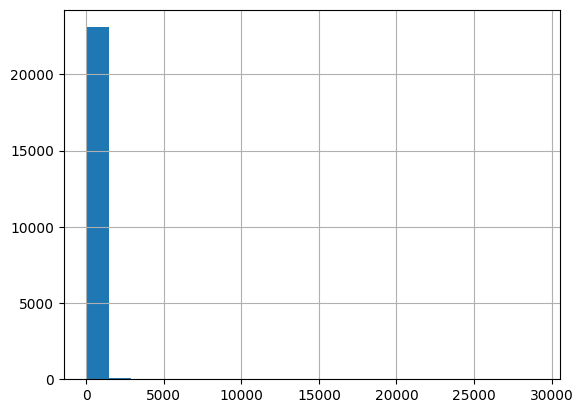

In [6]:
df["tweet_num"].hist(bins=20)

In [7]:
df.describe()

,tweet_num,label
count,23196.000000,23196.000000
mean,88.956803,0.751897
std,488.694592,0.431921
min,0.000000,0.000000
25%,11.000000,1.000000
50%,37.000000,1.000000
75%,65.000000,1.000000
max,29060.000000,1.000000


In [8]:
# correlation
df[["tweet_num", "label"]].corr()["label"]

tweet_num   -0.051411
label        1.000000
Name: label, dtype: float64

In [9]:
# map target values to strings (scikit-learn supports string labels)
labels = ["fake", "real"]
label_map = {
    0: "fake",
    1: "real"
}

df["label"] = df["label"].map(label_map)

/tmp/ipykernel_62534/1060152178.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(x=idx, y=label_counts[idx]+100, s=str(label_counts[idx]), ha="center")


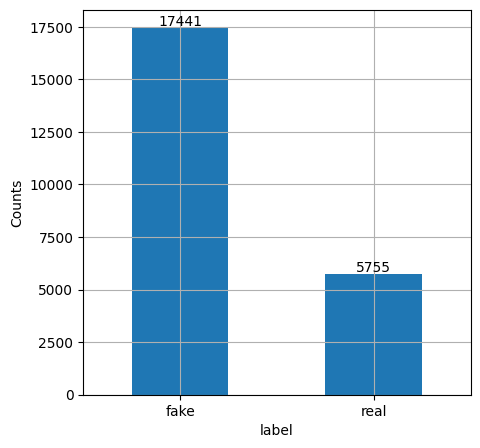

In [10]:
# check for data imbalance
import matplotlib.pyplot as plt
labels = ["fake", "real"]
label_counts = df["label"].value_counts()
plt.figure(figsize=(5, 5))
ax = label_counts.plot(kind="bar", rot=0, grid=True)
ax.set_ylabel("Counts")
ax.set_xticklabels(labels)

for idx, label in enumerate(label_counts.index):
    ax.text(x=idx, y=label_counts[idx]+100, s=str(label_counts[idx]), ha="center")
plt.show()


<Axes: ylabel='Frequency'>

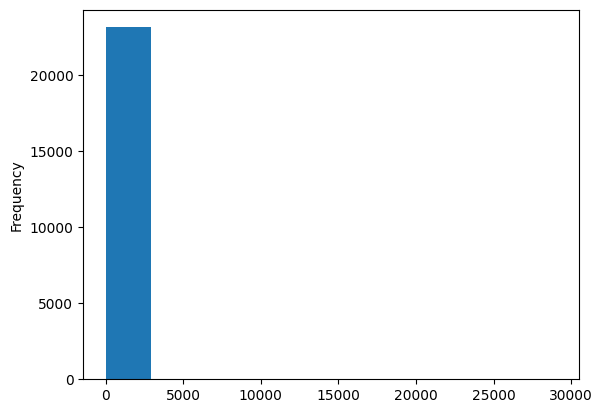

In [11]:
df["tweet_num"].plot.hist()

In [12]:
# view samples from the dataset
n_samples = 5
for i in np.random.permutation(len(df))[:n_samples]:
    print("Title:", df.iloc[i]["title"])
    print("URL:", df.iloc[i]["news_url"])
    print("Label:", df.iloc[i]["label"], end="\n\n")
    print("-*" * 50, end="\n\n")

Title: Scott Porter and Wife Kelsey Welcome a Daughter
URL: https://people.com/parents/scott-porter-wife-kelsey-welcome-daughter-clover-ash/
Label: real

-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*

Title: 'Dirty Dancing': How the TV Remake Compares to the Original
URL: https://ew.com/tv/2017/05/24/dirty-dancing-abc-tv-remake-vs-original/
Label: real

-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*

Title: 21 best Selena Gomez Hollywood Life images on Pinterest
URL: www.pinterest.co.uk/josh2578/selena-gomez-hollywood-life/
Label: fake

-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*

Title: Watch Out King Robert! A Coup Is Underway on The Royals and the King Is on the Chopping Block
URL: https://www.longroom.com/discussion/1001273/watch-out-king-robert-a-coup-is-underway-on-the-royals-and-the-king-is-on-the-chopping-block
Lab

In [13]:
# check for duplicates
print(df.duplicated().sum())

137


In [14]:
# drop duplicates
df = df.drop_duplicates(keep="first")
print(df.duplicated().sum())

0


In [15]:
# check for missing values
df.isnull().sum()

title              0
news_url         329
source_domain    329
tweet_num          0
label              0
dtype: int64

In [16]:
# view observations with missing data
df[df.isnull().sum(axis=1) > 0]

,title,news_url,source_domain,tweet_num,label
14,2011 via CQ subscribers only Tax Foundation,NaN,NaN,0,real
72,Patient Protection and Affordable Care Act,NaN,NaN,2437,real
87,Jennifer Lopez Snubbed Vanessa Hudgens On ‘ Se...,NaN,NaN,4,fake
177,Gwen Stefani Call Off Blake Shelton,NaN,NaN,85,fake
198,Angelina Jolie Attending Royal Wedding Specul...,NaN,NaN,3,fake
...,...,...,...,...,...
22915,Ariel Winter ’ s Friends She ’ s About To Elop...,NaN,NaN,2,fake
22997,2011 Urban InstituteBrookings Institution Tax ...,NaN,NaN,89,real
23011,Scott Disick Like Donald Trump Jr Donald Trump,NaN,NaN,55,fake
23102,Celebrity Insider Caught Plagiarizing Cop Fact...,NaN,NaN,0,fake


In [17]:
# extract source domain from news_url and take care of missing url
def extract_domain(url):
    from urllib.parse import urlparse
    if not url or type(url) == float:
        url = "unknown"
    parsed = urlparse(url)
    domain = parsed.netloc
    
    if not domain:
        return "unknown"
    
    elif domain.startswith("www."):
        domain = domain[4:]
    
    return domain.lower()

df["cleaned_source_domain"] = df["news_url"].apply(extract_domain)
df.head()

,title,news_url,source_domain,tweet_num,label,cleaned_source_domain
0,Kandi Burruss Explodes Over Rape Accusation on...,http://toofab.com/2017/05/08/real-housewives-a...,toofab.com,42,real,toofab.com
1,People's Choice Awards 2018: The best red carp...,https://www.today.com/style/see-people-s-choic...,www.today.com,0,real,today.com
2,Sophia Bush Sends Sweet Birthday Message to 'O...,https://www.etonline.com/news/220806_sophia_bu...,www.etonline.com,63,real,etonline.com
3,Colombian singer Maluma sparks rumours of inap...,https://www.dailymail.co.uk/news/article-33655...,www.dailymail.co.uk,20,real,dailymail.co.uk
4,Gossip Girl 10 Years Later: How Upper East Sid...,https://www.zerchoo.com/entertainment/gossip-g...,www.zerchoo.com,38,real,zerchoo.com


In [18]:
df["cleaned_source_domain"]

0             toofab.com
1              today.com
2           etonline.com
3        dailymail.co.uk
4            zerchoo.com
              ...       
23191      express.co.uk
23192            unknown
23193      justjared.com
23194            unknown
23195      billboard.com
Name: cleaned_source_domain, Length: 23059, dtype: object

In [19]:
# create training features
df["contents"] = df["cleaned_source_domain"] + " " + df["title"]
df.head()

,title,news_url,source_domain,tweet_num,label,cleaned_source_domain,contents
0,Kandi Burruss Explodes Over Rape Accusation on...,http://toofab.com/2017/05/08/real-housewives-a...,toofab.com,42,real,toofab.com,toofab.com Kandi Burruss Explodes Over Rape Ac...
1,People's Choice Awards 2018: The best red carp...,https://www.today.com/style/see-people-s-choic...,www.today.com,0,real,today.com,today.com People's Choice Awards 2018: The bes...
2,Sophia Bush Sends Sweet Birthday Message to 'O...,https://www.etonline.com/news/220806_sophia_bu...,www.etonline.com,63,real,etonline.com,etonline.com Sophia Bush Sends Sweet Birthday ...
3,Colombian singer Maluma sparks rumours of inap...,https://www.dailymail.co.uk/news/article-33655...,www.dailymail.co.uk,20,real,dailymail.co.uk,dailymail.co.uk Colombian singer Maluma sparks...
4,Gossip Girl 10 Years Later: How Upper East Sid...,https://www.zerchoo.com/entertainment/gossip-g...,www.zerchoo.com,38,real,zerchoo.com,zerchoo.com Gossip Girl 10 Years Later: How Up...


In [20]:
# fetch features and target variables
X = df["contents"]
y = df["label"]
X.head()

0    toofab.com Kandi Burruss Explodes Over Rape Ac...
1    today.com People's Choice Awards 2018: The bes...
2    etonline.com Sophia Bush Sends Sweet Birthday ...
3    dailymail.co.uk Colombian singer Maluma sparks...
4    zerchoo.com Gossip Girl 10 Years Later: How Up...
Name: contents, dtype: object

In [21]:
print(X.iloc[0])

toofab.com Kandi Burruss Explodes Over Rape Accusation on 'Real Housewives of Atlanta' Reunion (Video)


Split dataset

In [22]:
# split dataset
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [23]:
Xtrain.shape, Xtest.shape

((18447,), (4612,))

In [24]:
Xtrain.head()

7296     monstersandcritics.com Sceptical Brett Eldredg...
3213     babble.com Disney’s New ‘Freaky Friday’ Musica...
5600     hollywoodreporter.com Rebel Wilson, Jimmy Fall...
6543           celebritynetworth.com Paul Nassif Net Worth
14778    dailymail.co.uk Alexis Bledel reveals she has ...
Name: contents, dtype: object

Preprocess data

In [25]:

import numpy as np
from sklearn.feature_extraction.text import CountVectorizer

# instantiate transformers
count_vect = CountVectorizer()
tfidf_transformer = TfidfTransformer()


In [26]:
# transform train data
Xtrain_count = count_vect.fit_transform(Xtrain.values.squeeze())
train_features = tfidf_transformer.fit_transform(Xtrain_count).todense()
train_features = np.asarray(train_features)

In [27]:
# transform test data
Xtest_count = count_vect.transform(Xtest.values.squeeze())
test_features = tfidf_transformer.transform(Xtest_count).todense()
test_features = np.asarray(test_features)

Modeling

In [28]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression()
classifier.fit(train_features, ytrain)
train_accuracy = classifier.score(train_features, ytrain)
test_accuracy = classifier.score(test_features, ytest)

print(f"Train accuracy: {train_accuracy:.2f}")
print(f"Test accuracy: {test_accuracy:.2f}")

Train accuracy: 0.98
Test accuracy: 0.98


Build pipeline

In [29]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("count_vect", CountVectorizer()),
    ("transformer", TfidfTransformer()),
    ("classifier", LogisticRegression())
])

pipe.fit(Xtrain, ytrain)
pipe.score(Xtest, ytest)

0.9815698178664354

In [30]:
train_acc = pipe.score(Xtrain, ytrain)
test_acc = pipe.score(Xtest, ytest)
print("Train accuracy:", round(train_acc, ndigits=4)*100)
print("Test accuracy:", round(test_acc, 4)*100)

Train accuracy: 98.48
Test accuracy: 98.16


Evaluate pipeline

In [31]:

from sklearn import metrics

# classification report
test_pred = pipe.predict(Xtest)

report = metrics.classification_report(ytest, test_pred)
print(report)

              precision    recall  f1-score   support

        fake       0.99      0.94      0.96      1133
        real       0.98      1.00      0.99      3479

    accuracy                           0.98      4612
   macro avg       0.98      0.97      0.97      4612
weighted avg       0.98      0.98      0.98      4612



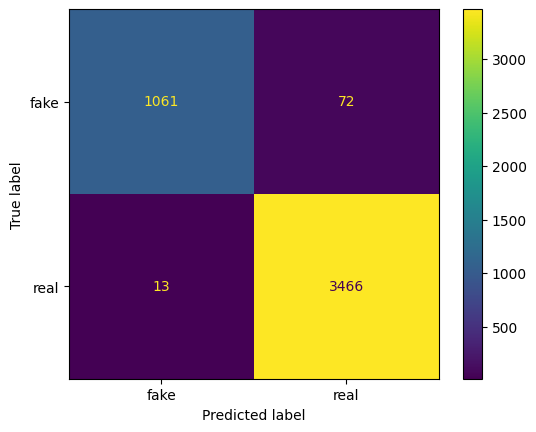

In [32]:
# confusion matrix
cm = metrics.confusion_matrix(ytest, test_pred)
cm_plot = metrics.ConfusionMatrixDisplay(cm, display_labels=list(label_map.values()))
cm_plot.plot()


Alternate pipeline (using TfidfVectorizer = CountVectorizer + TfidfTransformer)

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer

alt_pipe = Pipeline([
    ("transformer", TfidfVectorizer()),
    ("classifier", LogisticRegression())
    ])

alt_pipe.fit(Xtrain, ytrain)
alt_pipe.score(Xtest, ytest)

0.9815698178664354

Save model

In [34]:
model_path = "models/classifier.joblib"
os.makedirs(os.path.dirname(model_path), exist_ok=True)
joblib.dump(pipe, model_path)


['models/classifier.joblib']

## Save Test Data

In [35]:
# fetch columns to save
df_test = df.loc[Xtest.index][["news_url", "title", "label"]]
df_test.head()

,news_url,title,label
3662,https://people.com/tv/alyssa-milano-insatiable...,Alyssa Milano Responds to Fat-Shaming Backlash...,real
19986,https://www.today.com/news/princess-charlotte-...,"Princess Charlotte is the boss at home, the qu...",real
8157,https://people.com/tv/real-housewives-beverly-...,RHOBH: Eden Sassoon Leaving the Show After One...,real
21405,https://www.dailymail.co.uk/tvshowbiz/article-...,David Spade reveals moment he introduced his m...,real
16355,https://www.longroom.com/discussion/959311/the...,The Aaliyah x MAC Product Tease Is as Sultry a...,real


In [36]:
# reset data index
df_test = df_test.reset_index(drop=True)
df_test.head()

,news_url,title,label
0,https://people.com/tv/alyssa-milano-insatiable...,Alyssa Milano Responds to Fat-Shaming Backlash...,real
1,https://www.today.com/news/princess-charlotte-...,"Princess Charlotte is the boss at home, the qu...",real
2,https://people.com/tv/real-housewives-beverly-...,RHOBH: Eden Sassoon Leaving the Show After One...,real
3,https://www.dailymail.co.uk/tvshowbiz/article-...,David Spade reveals moment he introduced his m...,real
4,https://www.longroom.com/discussion/959311/the...,The Aaliyah x MAC Product Tease Is as Sultry a...,real


In [37]:
# save to csv
df_test.to_csv("data/test_fake_news.csv", index=False)

In [38]:
# save to json
df_test.to_json("data/test_fake_news.json", index=False)

### 📊 Insights
- The dataset contains 23,196 observations across 5 variables, providing a reasonably sized sample for model development.
- The target variable is imbalanced, with a higher proportion of real news compared to fake news. This may bias the model toward the majority class and should be addressed during training (e.g., through resampling or appropriate evaluation metrics).
- Duplicate records are present in the dataset and were identified and removed to ensure data quality and prevent training bias.
- Missing values were observed in the news_url and source_domain features. This is expected, as source_domain is derived from news_url. - Missing entries were handled by imputing a placeholder value ("unknown").
- The correlation between the target variable (labels) and the tweet_num feature is very weak, indicating that this feature contributes little predictive value and can be excluded from the training set.
- Some entries in the source_domain feature include the prefix "www.", which does not provide meaningful information. This was removed as part of preprocessing to ensure consistency and reduce noise in the feature.

### 🚀 Ideas for Improvement
- Apply word stemming or lemmatization
    - Reducing words to their base forms (e.g., running → run) can help decrease the dimensionality of the feature space, improve generalization, and lower computational cost during training.
- Explore the impact of URL protocols (http vs https)
    - Investigate whether the protocol type carries any predictive signal (e.g., credibility differences). This can be incorporated as a simple engineered feature and evaluated for its contribution to model performance.
- Implement custom text preprocessing pipelines
    - Enhance feature extraction by integrating custom preprocessors, tokenizers, and n-gram configurations within TfidfVectorizer/TfidfTransformer. This allows for better control over:
        - text normalization
        - stopword handling
        - token patterns
        - domain-specific feature engineering
- Leverage feature embeddings
    - Replace or complement TF-IDF features with dense vector representations (e.g., Word2Vec, GloVe, or transformer-based embeddings). This can capture semantic relationships between words while significantly reducing feature sparsity and dimensionality.